# Contrastive Causal Head Gating (CCHG)

This notebook demonstrates Contrastive CHG, which isolates sub-circuits for specific sub-tasks.

We use leave-one-out (LOO) training on function vector tasks to learn masks that:
- **Retain** performance on one prompt format (e.g., 10-shot ICL)
- **Forget** performance on another format (e.g., instruction-following)

This tests whether ICL and instruction-following rely on separable circuits.

In [ ]:
from pathlib import Path
import itertools
import os

import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import yaml

import chg
from chg.chg import CHG
from chg.chg_trainer import ContrastiveCHGTrainer
from chg.misc.tensordict_dataset import MaskedSequenceDataset, ContrastiveMaskedSequenceDataset

In [ ]:
project_root = Path(chg.__file__).parent.parent.parent
with open(project_root / "config.yaml") as f:
    config = yaml.safe_load(f)

directories = {k: Path(v) for k, v in config['directories'].items()}
os.environ['HF_HOME'] = str(directories['huggingface'])

from transformers import AutoTokenizer, AutoModelForCausalLM

device = 0

In [ ]:
model_name = 'meta-llama/Llama-3.2-3B-Instruct'
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model = model.eval()
for param in model.parameters():
    param.requires_grad = False

## Fit Contrastive Masks

For each held-out task, we fit a mask on the other 5 tasks.
- `10shot`: Retain 10-shot ICL, forget instruction-following
- `inst`: Retain instruction-following, forget 10-shot ICL

In [ ]:
loo_dir = directories['save'] / f'datasets/function_vectors_loo/{model_name}'
save_dir = directories['save'] / f'contrastive/{model_name}'
save_dir.mkdir(parents=True, exist_ok=True)

num_updates = 500

for path in tqdm(sorted(loo_dir.glob('*.pt'))):
    task_name, prompt_type = path.stem.split('_')
    mask_path = save_dir / f'{task_name}_{prompt_type}_mask.pt'
    log_path = save_dir / f'{task_name}_{prompt_type}_log.parquet'

    if mask_path.exists():
        print(f'Skipping {task_name}_{prompt_type}, mask already exists')
        continue

    print(f'Fitting {task_name}_{prompt_type}...')
    data = torch.load(path)
    dataset = ContrastiveMaskedSequenceDataset(
        pad_token_id=tokenizer.pad_token_id,
        positive_text_tokens=data['positive_text_tokens'].to(device),
        positive_loss_masks=data['positive_loss_masks'].to(device),
        negative_text_tokens=data['negative_text_tokens'].to(device),
        negative_loss_masks=data['negative_loss_masks'].to(device),
    )

    trainer = ContrastiveCHGTrainer(
        model=model,
        dataset=dataset,
        batch_size=64,
        lr=0.1,
        lr_end=0.01,
        l1_weight=0.1,
        max_diff=5,
    )

    rows = []
    for mask, metrics in trainer.fit(num_updates, mask_savepath=mask_path):
        rows.append(metrics)

    df = pd.DataFrame(rows)
    df.to_parquet(log_path)
    # break

## Evaluation

For each held-out task, evaluate accuracy with and without the fitted mask.

In [ ]:
def compute_accuracy(masked_model: CHG, mask: torch.Tensor, text_tokens: torch.Tensor, loss_masks: torch.Tensor, batch_size: int = 32) -> torch.Tensor:
    """Compute per-token accuracy on masked positions, batched to avoid OOM."""
    accuracies = []
    with torch.inference_mode():
        for i in tqdm(range(0, len(text_tokens), batch_size), desc='Evaluating', leave=False):
            batch_tokens = text_tokens[i:i+batch_size]
            batch_masks = loss_masks[i:i+batch_size]
            
            logits = masked_model(batch_tokens[:, :-1], mask)
            preds = logits.argmax(-1)
            targets = batch_tokens[:, 1:]
            masks = batch_masks[:, 1:]
            correct = (preds == targets) * masks
            accuracy = correct.sum(-1) / masks.sum(-1).clamp(min=1)
            accuracies.append(accuracy)
    return torch.cat(accuracies)

In [ ]:
fv_dir = directories['save'] / f'datasets/function_vectors/{model_name}'
mask_dir = directories['save'] / f'contrastive/{model_name}'

masked_model = CHG(model)
mask_default = torch.ones(masked_model.num_layers, masked_model.num_heads, dtype=torch.bfloat16, device=device)

rows = []
for mask_path in tqdm(sorted(mask_dir.glob('*_mask.pt'))):
    task, prompt_type = mask_path.stem.replace('_mask', '').split('_')
    mask = torch.load(mask_path).to(device).bfloat16()

    for eval_prompt_type, use_mask in itertools.product(['10shot', 'inst'], [True, False]):
        # Load train + validation data for this task/prompt combo
        train_data = torch.load(fv_dir / f'{task}_{eval_prompt_type}_train.pt')
        val_data = torch.load(fv_dir / f'{task}_{eval_prompt_type}_validation.pt')
        text_tokens = torch.cat([train_data['text_tokens'], val_data['text_tokens']]).to(device)
        loss_masks = torch.cat([train_data['loss_masks'], val_data['loss_masks']]).to(device)

        m = mask if use_mask else mask_default
        accuracy = compute_accuracy(masked_model, m, text_tokens, loss_masks)

        for i, acc in enumerate(accuracy.tolist()):
            rows.append({
                'task': task,
                'train_prompt': prompt_type,
                'eval_prompt': eval_prompt_type,
                'masked': use_mask,
                'problem_idx': i,
                'accuracy': acc,
            })

df_eval = pd.DataFrame(rows)
df_eval.to_parquet(mask_dir / 'evaluation.parquet')

## Results Summary

In [ ]:
# Aggregate accuracy by condition
summary = (
    df_eval
    .groupby(['task', 'train_prompt', 'eval_prompt', 'masked'])
    ['accuracy']
    .mean()
    .unstack('masked')
    .rename(columns={True: 'gated', False: 'default'})
    .reset_index()
)
summary['delta'] = summary['gated'] - summary['default']

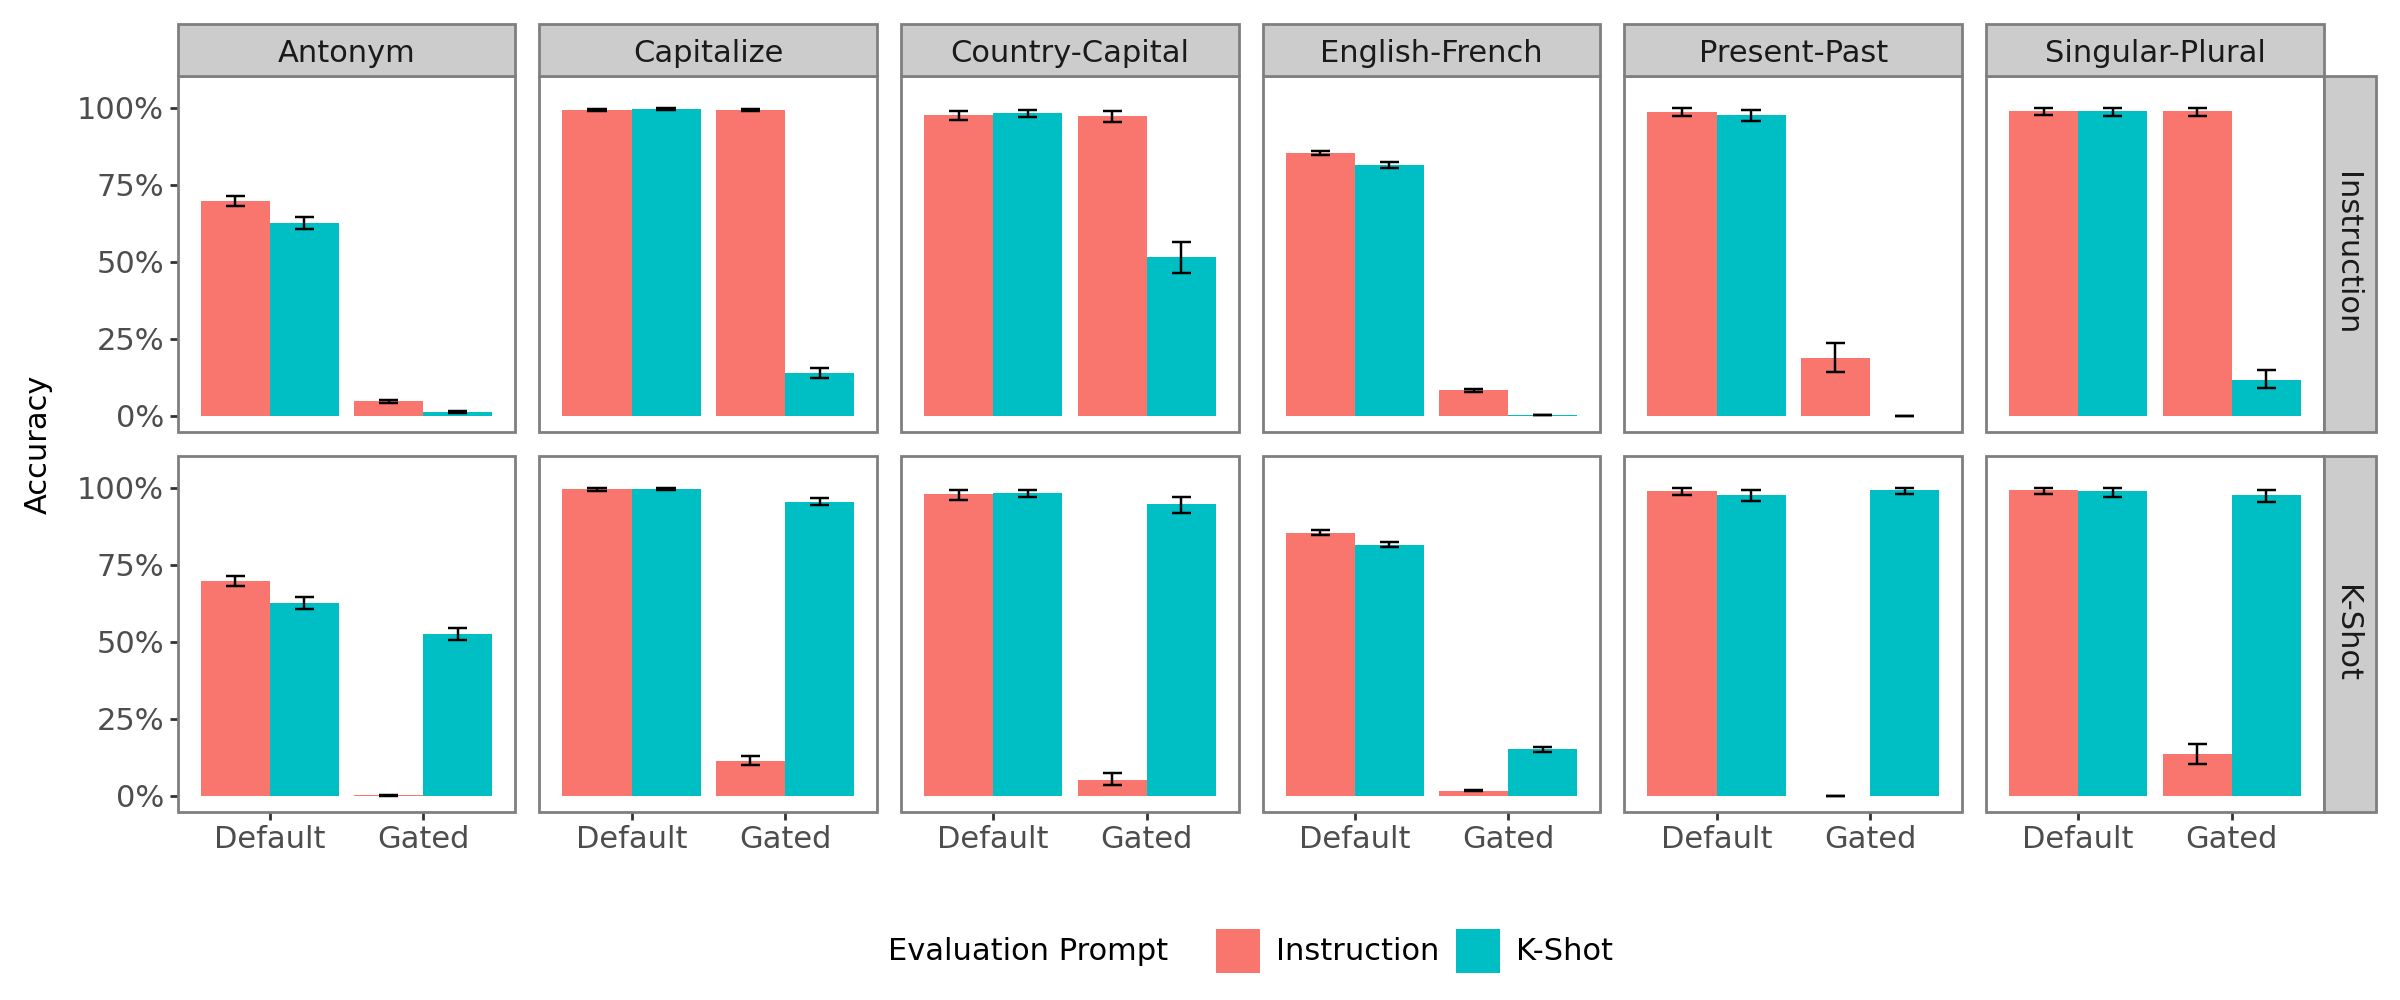

In [20]:
from plotnine import *
from mizani.formatters import percent_format
import numpy as np

# Prep data
plot_df = df_eval.copy()
plot_df['condition'] = plot_df['masked'].map({True: 'Gated', False: 'Default'})
plot_df['train_label'] = plot_df['train_prompt'].map({'inst': 'Instruction', '10shot': 'K-Shot'})
plot_df['eval_label'] = plot_df['eval_prompt'].map({'inst': 'Instruction', '10shot': 'K-Shot'})

task_labels = {
    'antonym': 'Antonym', 'capitalize': 'Capitalize', 'country-capital': 'Country-Capital',
    'english-french': 'English-French', 'present-past': 'Present-Past', 'singular-plural': 'Singular-Plural'
}
plot_df['task_label'] = plot_df['task'].map(task_labels)

# Set factor order
task_order = ['Antonym', 'Capitalize', 'Country-Capital', 'English-French', 'Present-Past', 'Singular-Plural']
plot_df['task_label'] = pd.Categorical(plot_df['task_label'], categories=task_order, ordered=True)
plot_df['train_label'] = pd.Categorical(plot_df['train_label'], categories=['Instruction', 'K-Shot'], ordered=True)
plot_df['condition'] = pd.Categorical(plot_df['condition'], categories=['Default', 'Gated'], ordered=True)

(
    ggplot(plot_df, aes(x='condition', y='accuracy', fill='eval_label'))
    + facet_grid('train_label ~ task_label')
    + stat_summary(fun_y=np.mean, geom='bar', position=position_dodge(width=0.9))
    + stat_summary(fun_data='mean_cl_boot', geom='errorbar', position=position_dodge(width=0.9), width=0.25)
    + scale_y_continuous(labels=percent_format(), limits=(0, 1.05))
    + labs(x='', y='Accuracy', fill='Evaluation Prompt')
    + theme_bw()
    + theme(
        figure_size=(12, 5),
        legend_position='bottom',
        text=element_text(size=11),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
    )
)